In [1]:
!pip install -q sentence-transformers PyMuPDF pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 22.8 MB/s eta 0:00:00


In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

pd.set_option("display.max_colwidth", 120)


In [3]:
SKILL_TAXONOMY = {
    "Programming Languages": ["python", "java", "c++", "c", "javascript", "typescript", "go", "rust",
                               "r", "sql", "kotlin", "swift", "php", "matlab", "scala"],
    "Web Development": ["html", "css", "react", "angular", "vue", "flask", "django", "fastapi",
                         "node.js", "express", "next.js", "rest api", "graphql", "bootstrap", "tailwind"],
    "Data & ML": ["machine learning", "deep learning", "nlp", "computer vision", "pytorch", "tensorflow",
                  "keras", "scikit-learn", "pandas", "numpy", "opencv", "bert", "transformers", "llm",
                  "generative ai", "mlops", "data analysis", "data visualization", "statistics",
                  "feature engineering"],
    "Databases": ["mysql", "postgresql", "mongodb", "sqlite", "redis", "oracle", "firebase",
                  "cassandra", "dynamodb"],
    "Cloud & DevOps": ["aws", "azure", "gcp", "docker", "kubernetes", "ci/cd", "jenkins", "terraform",
                        "linux", "git", "github actions", "nginx"],
    "Core CS": ["data structures", "algorithms", "oop", "operating systems", "computer networks",
                "system design", "dbms", "software engineering"],
}

SKILL_TO_CATEGORY = {s: cat for cat, skills in SKILL_TAXONOMY.items() for s in skills}
ALL_SKILLS = sorted(SKILL_TO_CATEGORY.keys(), key=len, reverse=True)
print(f"{len(ALL_SKILLS)} skills across {len(SKILL_TAXONOMY)} categories")


79 skills across 6 categories


In [4]:
# if you need upload real resume files in Colab
# from google.colab import files
# uploaded = files.upload()   # then extract text with fitz.open(filename) as shown in section 5b

job_description = '''
We are hiring a Machine Learning Engineer to build NLP and recommendation systems.
Required skills: Python, Machine Learning, Deep Learning, PyTorch, BERT, NLP, SQL, Docker, AWS.
2+ years of experience preferred. Familiarity with Transformers and MLOps is a plus.
'''

raw_resumes = {
    "Aditi Rao": '''
        Aditi Rao | aditi.rao@email.com | +91 90000 11111
        Machine learning engineer with 3 years experience building NLP pipelines using
        Python, PyTorch, and BERT-based transformers. Deployed models on AWS with Docker.
        Skilled in SQL, Scikit-learn, Pandas, Numpy, and MLOps practices.
        B.Tech in Computer Science.
    ''',
    "Karthik Iyer": '''
        Karthik Iyer | karthik.iyer@email.com | +91 90000 22222
        Frontend developer with 4 years experience in React, JavaScript, HTML, CSS, and Node.js.
        Some exposure to Python scripting and REST APIs. No formal ML background.
    ''',
    "Meera Nair": '''
        Meera Nair | meera.nair@email.com | +91 90000 33333
        Data scientist with 1.5 years experience in Machine Learning and Deep Learning.
        Proficient in Python, TensorFlow, Keras, NLP, and SQL. Currently learning Docker and AWS.
        M.Sc in Data Science.
    ''',
}

print(f"Loaded {len(raw_resumes)} sample resumes.")


Loaded 3 sample resumes.


In [5]:
EMAIL_RE = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
PHONE_RE = re.compile(r"(\+?\d{1,3}[-.\s]?)?\(?\d{3,5}\)?[-.\s]?\d{3,4}[-.\s]?\d{3,4}")
EXPERIENCE_RE = re.compile(r"(\d+(?:\.\d+)?)\s*\+?\s*(?:years|yrs|year)\s*(?:of)?\s*experience", re.I)

def extract_skills(text: str) -> list:
    lowered = text.lower()
    found = set()
    for skill in ALL_SKILLS:
        pattern = r"(?<![a-zA-Z0-9])" + re.escape(skill) + r"(?![a-zA-Z0-9])"
        if re.search(pattern, lowered):
            found.add(skill)
    return sorted(found)

def estimate_experience_years(text: str) -> float:
    matches = EXPERIENCE_RE.findall(text)
    return max((float(m) for m in matches), default=0.0)

def parse_resume_text(name: str, text: str) -> dict:
    email = EMAIL_RE.search(text)
    phone = PHONE_RE.search(text)
    skills = extract_skills(text)
    return {
        "name": name,
        "email": email.group() if email else None,
        "phone": phone.group().strip() if phone else None,
        "skills": skills,
        "experience_years": estimate_experience_years(text),
        "raw_text": text.strip(),
    }

parsed_candidates = [parse_resume_text(name, text) for name, text in raw_resumes.items()]
pd.DataFrame(parsed_candidates)[["name", "email", "experience_years", "skills"]]


,name,email,experience_years,skills
0,Aditi Rao,aditi.rao@email.com,3.0,"[aws, bert, docker, machine learning, mlops, nlp, numpy, pandas, python, pytorch, scikit-learn, sql, transformers]"
1,Karthik Iyer,karthik.iyer@email.com,4.0,"[css, html, javascript, node.js, python, react]"
2,Meera Nair,meera.nair@email.com,1.5,"[aws, deep learning, docker, keras, machine learning, nlp, python, sql, tensorflow]"


In [6]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded:", model)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [7]:
def semantic_similarity(text_a: str, text_b: str) -> float:
    emb = model.encode([text_a, text_b], convert_to_tensor=True, normalize_embeddings=True)
    score = util.cos_sim(emb[0], emb[1]).item()
    return max(0.0, min(1.0, (score + 1) / 2 if score < 0 else score))

for c in parsed_candidates:
    c["semantic_score"] = round(semantic_similarity(c["raw_text"], job_description) * 100, 1)

pd.DataFrame(parsed_candidates)[["name", "semantic_score"]].sort_values("semantic_score", ascending=False)


,name,semantic_score
0,Aditi Rao,68.3
2,Meera Nair,42.0
1,Karthik Iyer,35.1


In [8]:
job_skills = extract_skills(job_description)
required_experience = 2.0
print("Required skills detected from JD:", job_skills)

def skill_overlap_score(resume_skills, jd_skills):
    if not jd_skills:
        return 0.0
    matched = set(resume_skills) & set(jd_skills)
    return len(matched) / len(set(jd_skills))

def verdict(score):
    if score >= 80: return "Excellent Match"
    if score >= 65: return "Strong Match"
    if score >= 45: return "Moderate Match"
    return "Weak Match"

for c in parsed_candidates:
    kw_score = skill_overlap_score(c["skills"], job_skills)
    exp_score = min(1.0, c["experience_years"] / required_experience) if required_experience > 0 else 1.0
    sem_score = c["semantic_score"] / 100

    final = 0.40 * sem_score + 0.40 * kw_score + 0.20 * exp_score
    c["keyword_score"] = round(kw_score * 100, 1)
    c["experience_score"] = round(exp_score * 100, 1)
    c["ats_score"] = round(final * 100, 1)
    c["verdict"] = verdict(c["ats_score"])

pd.DataFrame(parsed_candidates)[["name", "semantic_score", "keyword_score", "experience_score", "ats_score", "verdict"]]


Required skills detected from JD: ['aws', 'bert', 'deep learning', 'docker', 'machine learning', 'mlops', 'nlp', 'python', 'pytorch', 'sql', 'transformers']


,name,semantic_score,keyword_score,experience_score,ats_score,verdict
0,Aditi Rao,68.3,90.9,100.0,83.7,Excellent Match
1,Karthik Iyer,35.1,9.1,100.0,37.7,Weak Match
2,Meera Nair,42.0,63.6,75.0,57.3,Moderate Match


In [9]:
def skill_gap(resume_skills, jd_skills):
    resume_set, jd_set = set(resume_skills), set(jd_skills)
    matched = sorted(resume_set & jd_set)
    missing = sorted(jd_set - resume_set)
    missing_by_category = {}
    for s in missing:
        cat = SKILL_TO_CATEGORY.get(s, "Other")
        missing_by_category.setdefault(cat, []).append(s)
    return {"matched": matched, "missing": missing, "missing_by_category": missing_by_category}

for c in parsed_candidates:
    gap = skill_gap(c["skills"], job_skills)
    c["matched_skills"] = gap["matched"]
    c["missing_skills"] = gap["missing"]
    print(f"--- {c['name']} ---")
    print("  Matched:", gap["matched"])
    print("  Missing:", gap["missing"])


--- Aditi Rao ---
  Matched: ['aws', 'bert', 'docker', 'machine learning', 'mlops', 'nlp', 'python', 'pytorch', 'sql', 'transformers']
  Missing: ['deep learning']
--- Karthik Iyer ---
  Matched: ['python']
  Missing: ['aws', 'bert', 'deep learning', 'docker', 'machine learning', 'mlops', 'nlp', 'pytorch', 'sql', 'transformers']
--- Meera Nair ---
  Matched: ['aws', 'deep learning', 'docker', 'machine learning', 'nlp', 'python', 'sql']
  Missing: ['bert', 'mlops', 'pytorch', 'transformers']


In [10]:
ranked = sorted(parsed_candidates, key=lambda c: c["ats_score"], reverse=True)
for i, c in enumerate(ranked, start=1):
    c["rank"] = i

rank_df = pd.DataFrame(ranked)[["rank", "name", "ats_score", "verdict"]]
rank_df


,rank,name,ats_score,verdict
0,1,Aditi Rao,83.7,Excellent Match
1,2,Meera Nair,57.3,Moderate Match
2,3,Karthik Iyer,37.7,Weak Match


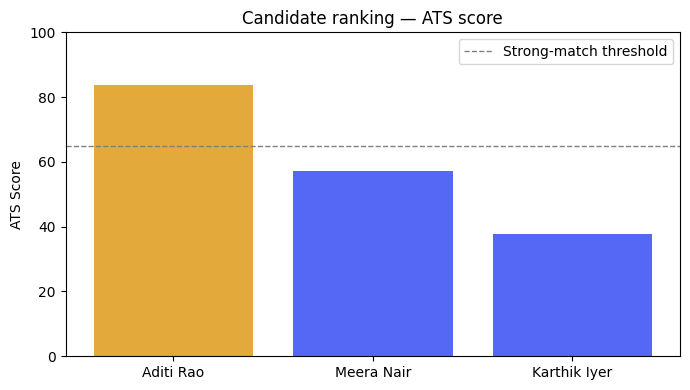

In [11]:
plt.figure(figsize=(7, 4))
names = [c["name"] for c in ranked]
scores = [c["ats_score"] for c in ranked]
colors = ["#e4a93b" if i == 0 else "#5468f5" for i in range(len(ranked))]
plt.bar(names, scores, color=colors)
plt.axhline(65, color="gray", linestyle="--", linewidth=1, label="Strong-match threshold")
plt.ylabel("ATS Score")
plt.title("Candidate ranking — ATS score")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
def split_sentences(text):
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if 6 <= len(s.split()) <= 60]

def summarize_resume(resume_text, name, top_k=3):
    sentences = split_sentences(resume_text)
    if len(sentences) <= top_k:
        return " ".join(sentences)
    embeddings = model.encode(sentences, convert_to_tensor=True, normalize_embeddings=True)
    doc_embedding = embeddings.mean(dim=0)
    scores = util.cos_sim(doc_embedding, embeddings)[0]
    top_idx = sorted(range(len(sentences)), key=lambda i: scores[i], reverse=True)[:top_k]
    top_idx.sort()
    return f"{name} — " + " ".join(sentences[i] for i in top_idx)

for c in ranked:
    c["summary"] = summarize_resume(c["raw_text"], c["name"])
    print(f"\n{c['name']}:\n{c['summary']}")



Aditi Rao:
Aditi Rao | aditi.rao@email.com | +91 90000 11111 Machine learning engineer with 3 years experience building NLP pipelines using Python, PyTorch, and BERT-based transformers. Deployed models on AWS with Docker. Skilled in SQL, Scikit-learn, Pandas, Numpy, and MLOps practices.

Meera Nair:
Meera Nair | meera.nair@email.com | +91 90000 33333 Data scientist with 1.5 years experience in Machine Learning and Deep Learning. Proficient in Python, TensorFlow, Keras, NLP, and SQL.

Karthik Iyer:
Karthik Iyer | karthik.iyer@email.com | +91 90000 22222 Frontend developer with 4 years experience in React, JavaScript, HTML, CSS, and Node.js. Some exposure to Python scripting and REST APIs.


In [13]:
TECHNICAL_QUESTION_BANK = {
    "python": ["Explain the difference between a list and a tuple in Python.",
               "What are Python decorators and when would you use one?"],
    "sql": ["What's the difference between INNER JOIN and LEFT JOIN?",
            "How would you optimize a slow-running SQL query?"],
    "machine learning": ["How would you handle an imbalanced dataset?",
                          "Explain the bias-variance tradeoff."],
    "deep learning": ["What's the difference between a CNN and an RNN?",
                       "How do you prevent a neural network from overfitting?"],
    "bert": ["How does BERT's attention mechanism differ from earlier NLP models?",
              "What's the difference between BERT and Sentence-BERT?"],
    "docker": ["What's the difference between a Docker image and a container?"],
    "aws": ["What's the difference between an EC2 instance and a Lambda function?"],
}

HR_QUESTIONS = [
    "Tell me about yourself and what draws you to this role.",
    "Describe a challenging project you worked on and how you handled obstacles.",
    "How do you prioritize tasks when working under tight deadlines?",
]

def generate_questions(matched_skills, n_technical=5):
    technical = []
    for skill in matched_skills:
        for q in TECHNICAL_QUESTION_BANK.get(skill, []):
            if q not in technical:
                technical.append(q)
        if len(technical) >= n_technical:
            break
    return technical[:n_technical], HR_QUESTIONS

for c in ranked:
    tech_qs, hr_qs = generate_questions(c["matched_skills"])
    c["technical_questions"] = tech_qs
    c["hr_questions"] = hr_qs
    print(f"\n=== {c['name']} — Technical Questions ===")
    for q in tech_qs:
        print(" -", q)



=== Aditi Rao — Technical Questions ===
 - What's the difference between an EC2 instance and a Lambda function?
 - How does BERT's attention mechanism differ from earlier NLP models?
 - What's the difference between BERT and Sentence-BERT?
 - What's the difference between a Docker image and a container?
 - How would you handle an imbalanced dataset?

=== Meera Nair — Technical Questions ===
 - What's the difference between an EC2 instance and a Lambda function?
 - What's the difference between a CNN and an RNN?
 - How do you prevent a neural network from overfitting?
 - What's the difference between a Docker image and a container?
 - How would you handle an imbalanced dataset?

=== Karthik Iyer — Technical Questions ===
 - Explain the difference between a list and a tuple in Python.
 - What are Python decorators and when would you use one?


In [14]:
export_df = pd.DataFrame(ranked)[[
    "rank", "name", "email", "ats_score", "semantic_score", "keyword_score",
    "experience_score", "verdict", "matched_skills", "missing_skills"
]]
export_df.to_csv("ranked_candidates.csv", index=False)

with open("ranked_candidates.json", "w") as f:
    json.dump(ranked, f, indent=2)

print("Saved ranked_candidates.csv and ranked_candidates.json")
export_df


Saved ranked_candidates.csv and ranked_candidates.json


,rank,name,email,ats_score,semantic_score,keyword_score,experience_score,verdict,matched_skills,missing_skills
0,1,Aditi Rao,aditi.rao@email.com,83.7,68.3,90.9,100.0,Excellent Match,"[aws, bert, docker, machine learning, mlops, nlp, python, pytorch, sql, transformers]",[deep learning]
1,2,Meera Nair,meera.nair@email.com,57.3,42.0,63.6,75.0,Moderate Match,"[aws, deep learning, docker, machine learning, nlp, python, sql]","[bert, mlops, pytorch, transformers]"
2,3,Karthik Iyer,karthik.iyer@email.com,37.7,35.1,9.1,100.0,Weak Match,[python],"[aws, bert, deep learning, docker, machine learning, mlops, nlp, pytorch, sql, transformers]"
